In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

scarf.fetch_dataset(
    'tenx_5K_pbmc_rnaseq',
    save_path='scarf_datasets'
)

In [2]:
reader = scarf.CrH5Reader('scarf_datasets/tenx_5K_pbmc_rnaseq/data.h5')
reader.nCells, reader.nFeatures

(5025, 33538)

In [3]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc='scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    chunk_size=(2000, 1000)
)
writer.dump(batch_size=1000)

In [4]:
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10
)
ds

Minimum cell count (502) is lower than size factor multiplier (1000)



DataStore has 5025 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentRibo', 'RNA_percentMito', 
            'RNA_nFeatures', 'RNA_nCounts'
   RNA assay has 14283 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

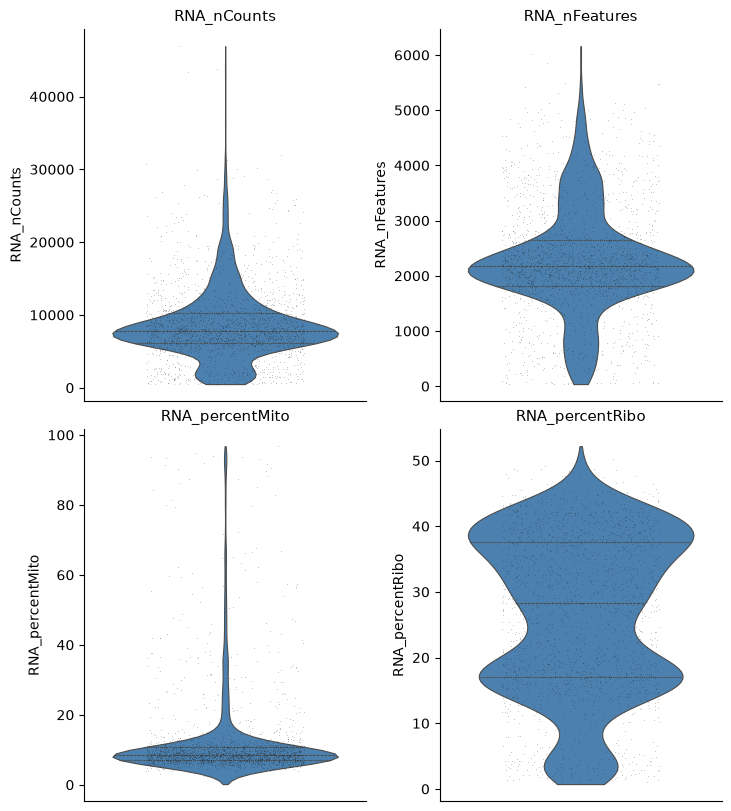

PlotResult(axes=4, tables=4, legends=1, scales=0, owns_figure=True, rendered=True)

In [5]:
qc_cols = [
    c for c in (
        'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'
    )
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

In [6]:
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0]
)

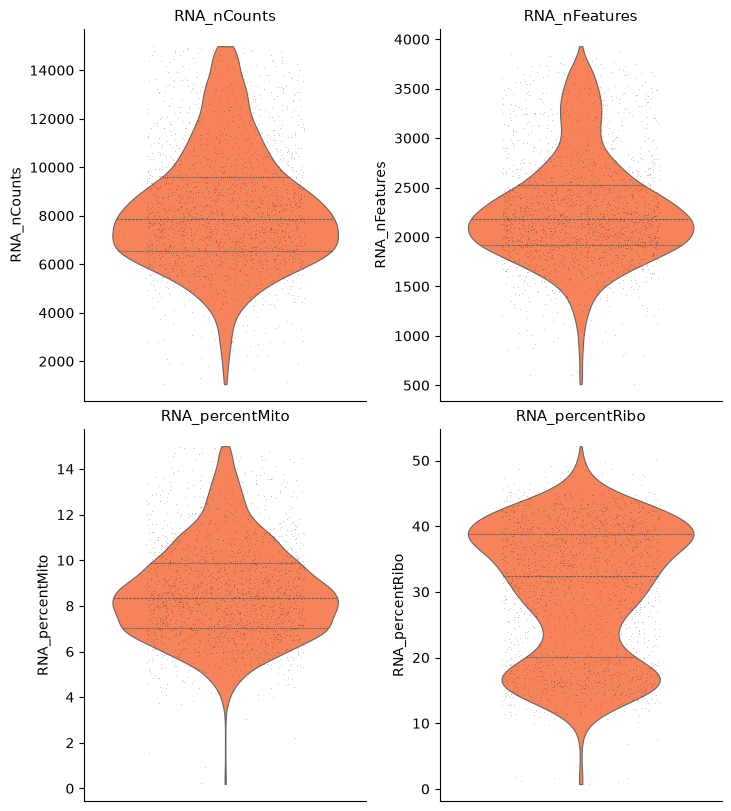

,I,ids,names,RNA_percentMito,RNA_nCounts,RNA_percentRibo,RNA_nFeatures
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,10.844353,13537.0,16.783630,3503.0
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,5.975687,12668.0,20.034733,3381.0
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,53.430353,962.0,2.494802,346.0
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,10.919143,5788.0,28.783690,1799.0
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,7.955407,13186.0,35.750038,2887.0


In [7]:
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
    color='coral',
)
ds.cells.head()

In [8]:
ds.RNA.sf

1000

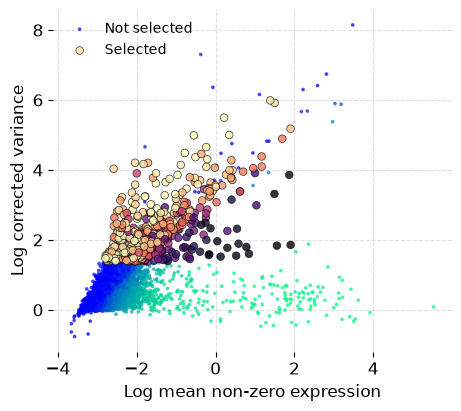

,I,ids,names,I__hvgs,nCells,dropOuts,stats_I_sigmas,stats_I_normed_n,stats_I_avg,stats_I_normed_tot,stats_I_nz_mean,stats_I_c_var__200__0.1
0,False,ENSG00000243485,MIR1302-2HG,False,0,5025,NaN,NaN,NaN,NaN,NaN,NaN
1,False,ENSG00000237613,FAM138A,False,0,5025,NaN,NaN,NaN,NaN,NaN,NaN
2,False,ENSG00000186092,OR4F5,False,0,5025,NaN,NaN,NaN,NaN,NaN,NaN
3,True,ENSG00000238009,AL627309.1,False,49,4976,0.000196,33.0,0.001166,4.593283,0.13919,1.5279
4,False,ENSG00000239945,AL627309.3,False,3,5022,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    min_mean=-3,
    max_mean=2,
    max_var=6
)
ds.RNA.feats.head()

In [10]:
ds.make_graph(
    feat_key='hvgs',
    k=11,
    dims=15,
    n_centroids=100
)

In [11]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)
ds.cells.head()

,I,ids,names,RNA_percentRibo,RNA_percentMito,RNA_nCounts,RNA_nFeatures,RNA_UMAP2,RNA_UMAP1
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,16.783630,10.844353,13537.0,3503.0,23.287539,8.144751
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,20.034733,5.975687,12668.0,3381.0,27.235439,-8.468659
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,2.494802,53.430353,962.0,346.0,NaN,NaN
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,28.783690,10.919143,5788.0,1799.0,14.287636,-2.321378
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,35.750038,7.955407,13186.0,2887.0,-7.529682,-24.649136


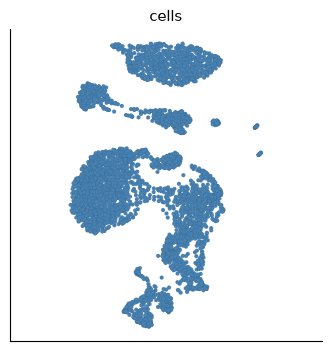

PlotResult(axes=1, tables=0, legends=0, scales=1, owns_figure=True, rendered=True)

In [12]:
ds.plots.embedding(layout_key='RNA_UMAP')

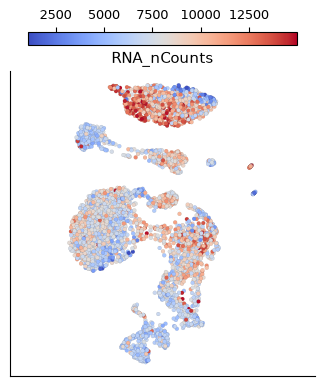

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [13]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
    color_scale=splt.ColorScale(cmap='coolwarm'),
)

In [14]:
ds.run_leiden_clustering(resolution=0.5)

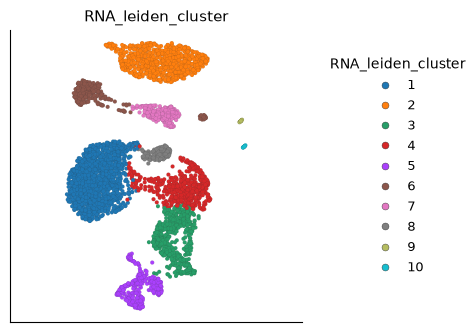

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [15]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [16]:
leiden_clusters = ds.cells.to_pandas_dataframe(
    columns=['RNA_leiden_cluster'],
    key='I'
)
leiden_clusters.head()

,RNA_leiden_cluster
0,2
1,2
3,7
4,1
6,5


In [17]:
ds.run_marker_search(
    group_key='RNA_leiden_cluster',
    gene_batch_size=100
)

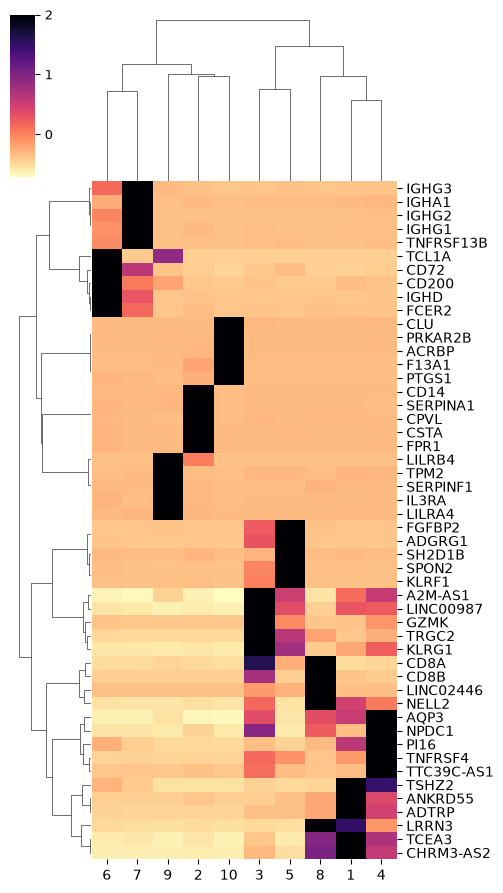

PlotResult(axes=4, tables=2, legends=1, scales=2, owns_figure=True, rendered=True)

In [18]:
ds.plots.marker_heatmap(
    group_key='RNA_leiden_cluster',
    topn=5,
    figsize=(5, 9)
)

In [19]:
df = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1
)
df.head()

,group_id,feature_name,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,feature_index
0,1,ADTRP,0.64732,0.04316,0.00283,0.23978,0.02265,15.26714,1.987595e-109,4325
1,1,ANKRD55,0.55468,0.02194,0.00123,0.14836,0.01003,17.77451,4.367807e-72,3795
2,1,TSHZ2,0.51036,0.07179,0.01107,0.32638,0.05050,6.48604,1.951616e-121,12544
3,1,TCEA3,0.48633,0.03191,0.00421,0.21091,0.03342,7.57451,1.767758e-75,225
4,1,CHRM3-AS2,0.48186,0.06784,0.00849,0.38332,0.05941,7.98771,6.859238e-150,1437


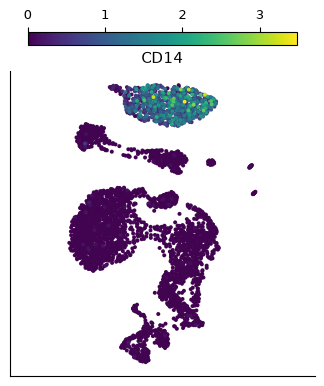

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [20]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='CD14',
    sort_values=True,
)